In [ ]:
## 1. package
import numpy as np  ##array
import pandas as pd #dataframe
import matplotlib.pyplot as plt
from IPython.display import display  # view dataframe wothout print
import seaborn as sns

In [ ]:
###2. data

from google.colab import files
import pandas as pd

uploaded = files.upload()
filename = next(iter(uploaded))
df= pd.read_csv(filename)



Saving Churn (1).csv to Churn (1).csv


In [ ]:
###3.Insights About The Dataset
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df.isnull().sum()
df[df["TotalCharges"].isna()]
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)

In [ ]:
n_dupes = df.duplicated().sum()
print("Full-row duplicate count:", n_dupes)

Full-row duplicate count: 0


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
missing = df.isna().sum().sort_values(ascending=False)

print(missing)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
####Validity checks
import pandas as pd

def count_invalid(series, rule_name, mask):
    return pd.Series({
        "rule": rule_name,
        "invalid_count": int(mask.sum()),
        "invalid_pct": float((mask.mean() * 100) if len(mask) else 0.0),
        "example_values": list(series[mask].head(5).values)
    })

checks = []
df_eda = df.copy()

# -----------------------------
# 1) Numeric validity checks
# -----------------------------
# tenure: should be between 0 and 72 (common in this dataset)
if "tenure" in df_eda.columns:
    m = (df_eda["tenure"] < 0) | (df_eda["tenure"] > 72)
    checks.append(count_invalid(df_eda["tenure"], "tenure < 0 or tenure > 72", m))

# MonthlyCharges: should be > 0
if "MonthlyCharges" in df_eda.columns:
    m = df_eda["MonthlyCharges"] <= 0
    checks.append(count_invalid(df_eda["MonthlyCharges"], "MonthlyCharges <= 0", m))

# TotalCharges: should be >= 0 OR missing allowed (we'll report missing separately)
if "TotalCharges" in df_eda.columns:
    m_missing = df_eda["TotalCharges"].isna()
    checks.append(count_invalid(df_eda["TotalCharges"], "TotalCharges is missing", m_missing))

    m_negative = df_eda["TotalCharges"].notna() & (df_eda["TotalCharges"] < 0)
    checks.append(count_invalid(df_eda["TotalCharges"], "TotalCharges < 0", m_negative))

# SeniorCitizen: should be 0 or 1
if "SeniorCitizen" in df_eda.columns:
    m = ~df_eda["SeniorCitizen"].isin([0, 1])
    checks.append(count_invalid(df_eda["SeniorCitizen"], "SeniorCitizen not in {0,1}", m))

# -----------------------------
# 2) Consistency (cross-field) checks
# -----------------------------
# If tenure == 0, TotalCharges should be 0 or missing (business logic)
if {"tenure", "TotalCharges"}.issubset(df_eda.columns):
    m = (df_eda["tenure"] == 0) & df_eda["TotalCharges"].notna() & (df_eda["TotalCharges"] != 0)
    checks.append(count_invalid(df_eda["TotalCharges"], "tenure==0 but TotalCharges != 0", m))

# If PhoneService == "No", MultipleLines should be "No phone service" or "No"
if {"PhoneService", "MultipleLines"}.issubset(df_eda.columns):
    m = (df_eda["PhoneService"] == "No") & (~df_eda["MultipleLines"].isin(["No", "No phone service"]))
    checks.append(count_invalid(df_eda["MultipleLines"], "PhoneService==No but MultipleLines not in {No, No phone service}", m))

# If InternetService == "No", internet-dependent services should be "No internet service" or "No"
internet_dependent = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
if "InternetService" in df_eda.columns:
    for c in internet_dependent:
        if c in df_eda.columns:
            m = (df_eda["InternetService"] == "No") & (~df_eda[c].isin(["No", "No internet service"]))
            checks.append(count_invalid(df_eda[c], f"InternetService==No but {c} not in {{No, No internet service}}", m))

# -----------------------------
# Output report
# -----------------------------
validity_report = pd.DataFrame(checks).sort_values("invalid_count", ascending=False).reset_index(drop=True)
validity_report


,rule,invalid_count,invalid_pct,example_values
0,tenure < 0 or tenure > 72,0,0.0,[]
1,MonthlyCharges <= 0,0,0.0,[]
2,TotalCharges is missing,0,0.0,[]
3,TotalCharges < 0,0,0.0,[]
4,"SeniorCitizen not in {0,1}",0,0.0,[]
5,tenure==0 but TotalCharges != 0,0,0.0,[]
6,"PhoneService==No but MultipleLines not in {No,...",0,0.0,[]
7,InternetService==No but OnlineSecurity not in ...,0,0.0,[]
8,InternetService==No but OnlineBackup not in {N...,0,0.0,[]
9,InternetService==No but DeviceProtection not i...,0,0.0,[]


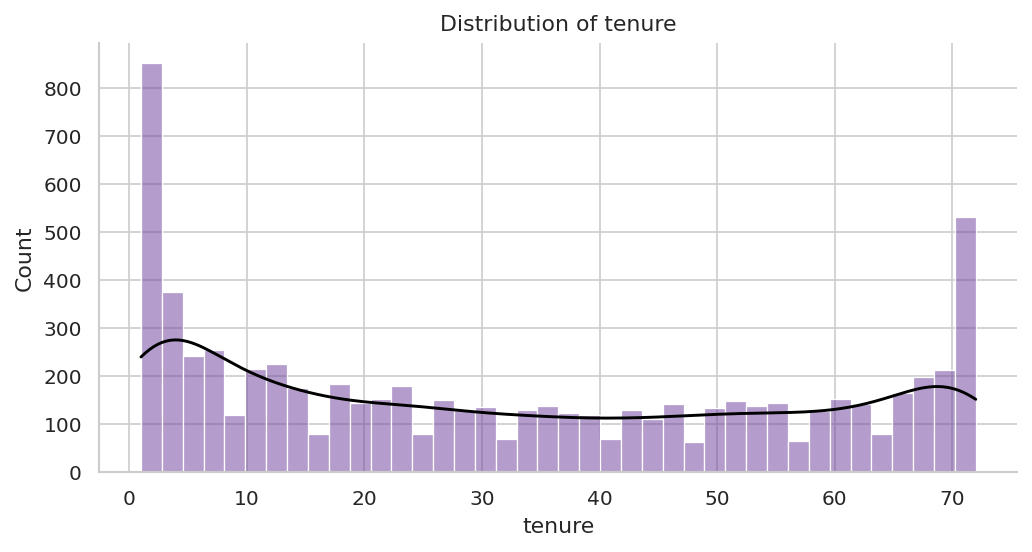

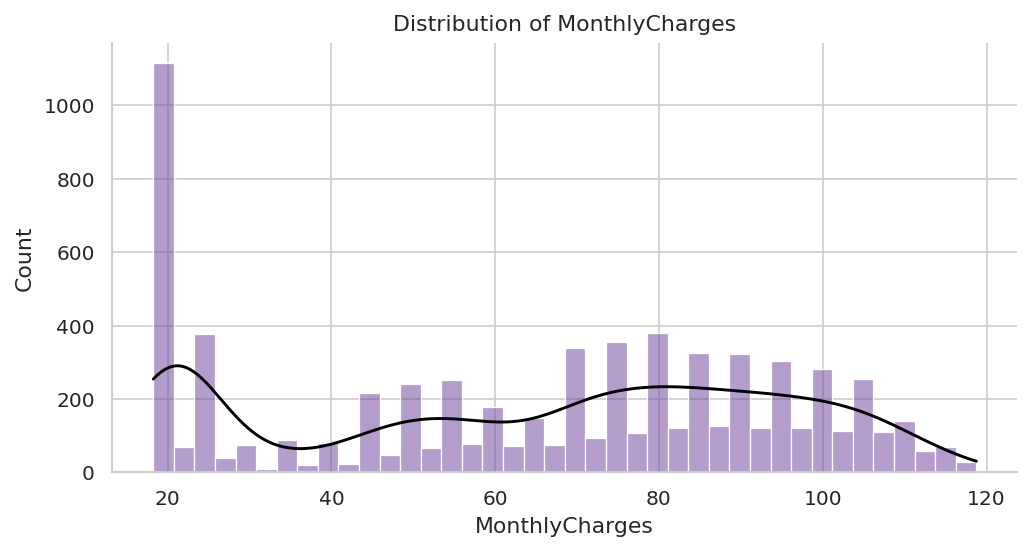

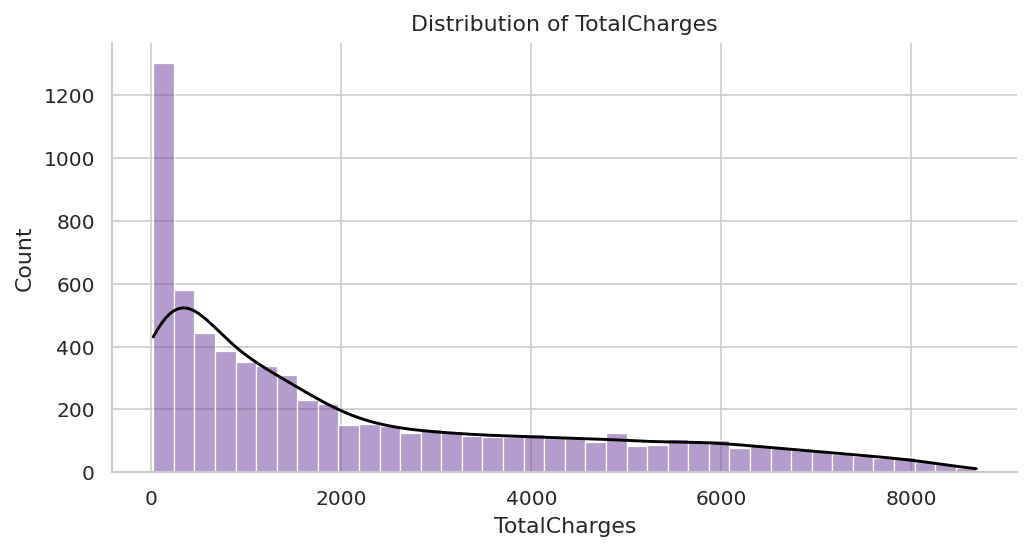

/tmp/ipython-input-707/3591406214.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="SeniorCitizen", data=df, palette=["#132730", "#211330"])  # 0, ثم 1


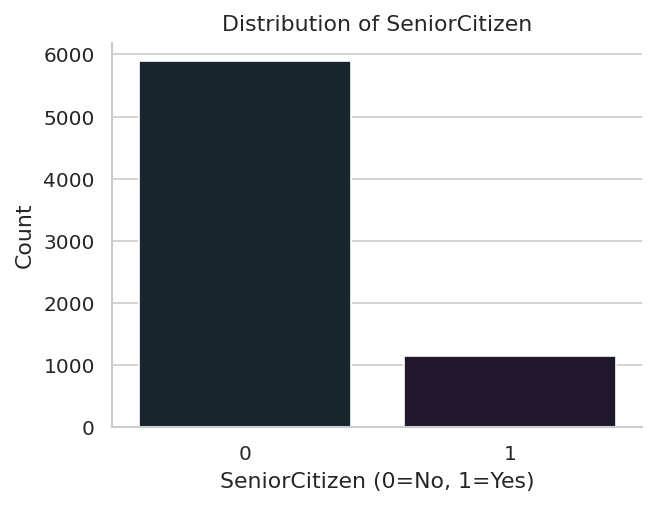

In [ ]:
###5.Univariate analysis
########5.1 numeric
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False
})

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

hist_color  = "#6A3D9A"   # blue
count_color = "#D55E00"   # vermillion (للـ SeniorCitizen)

for col in num_cols:
    x = df[col].dropna()

    plt.figure(figsize=(7, 3.8))
    ax = sns.histplot(
        x, bins=40, kde=True,
        color=hist_color, edgecolor="white", linewidth=0.6
    )

    if ax.lines:
        ax.lines[0].set_color("#000000")
        ax.lines[0].set_linewidth(1.4)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()

    plt.savefig(f"univariate_hist_{col}.png", facecolor="white", edgecolor="none")
    plt.savefig(f"univariate_hist_{col}.pdf", bbox_inches="tight")
    plt.show()

# SeniorCitizen كـ Binary
plt.figure(figsize=(4.5, 3.5))
sns.countplot(x="SeniorCitizen", data=df, palette=["#132730", "#211330"])  # 0, ثم 1
plt.title("Distribution of SeniorCitizen")
plt.xlabel("SeniorCitizen (0=No, 1=Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("univariate_count_SeniorCitizen.png", facecolor="white", edgecolor="none", dpi=300)
plt.show()

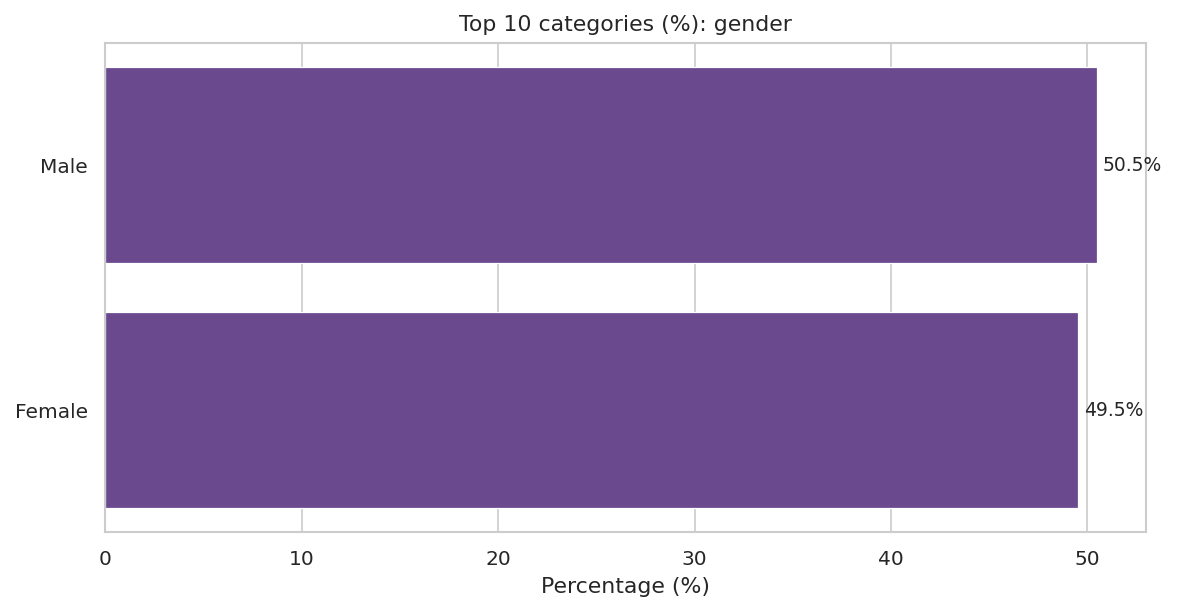

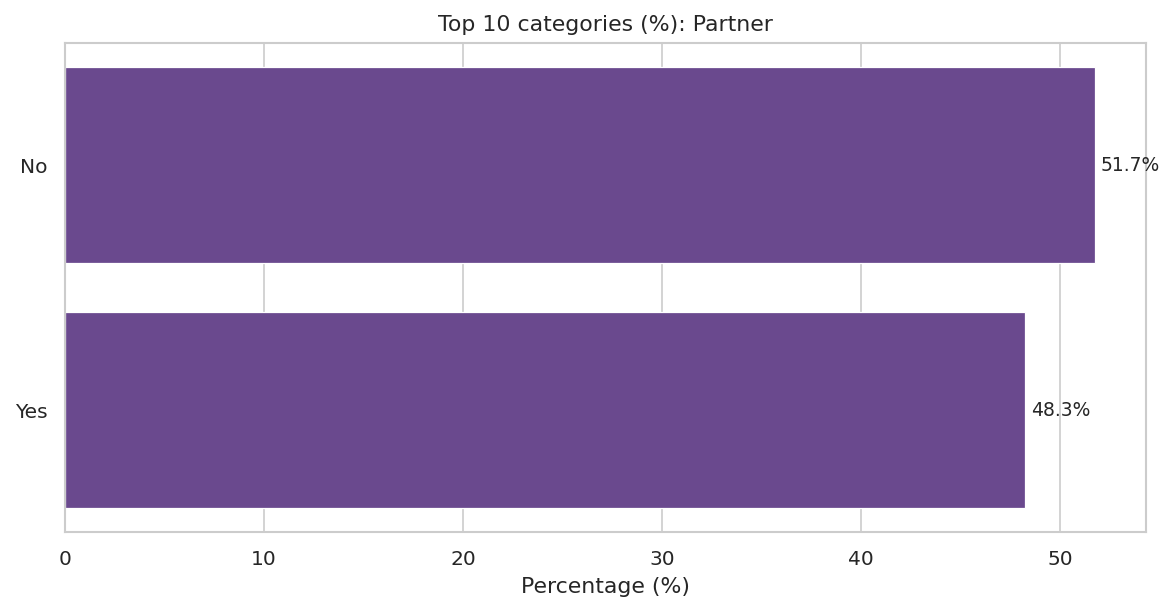

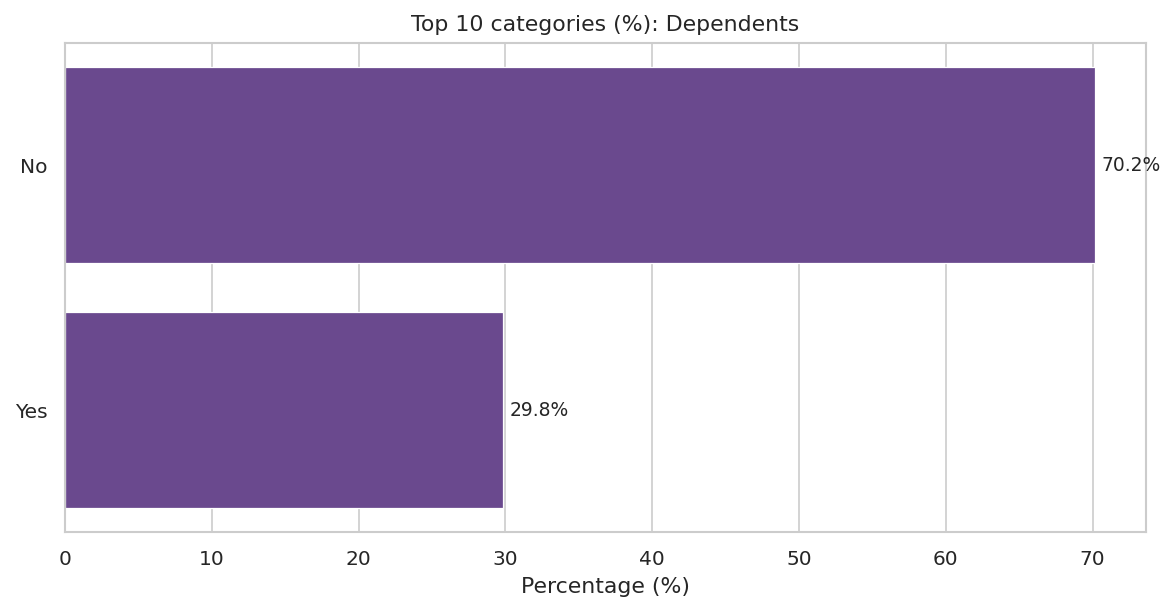

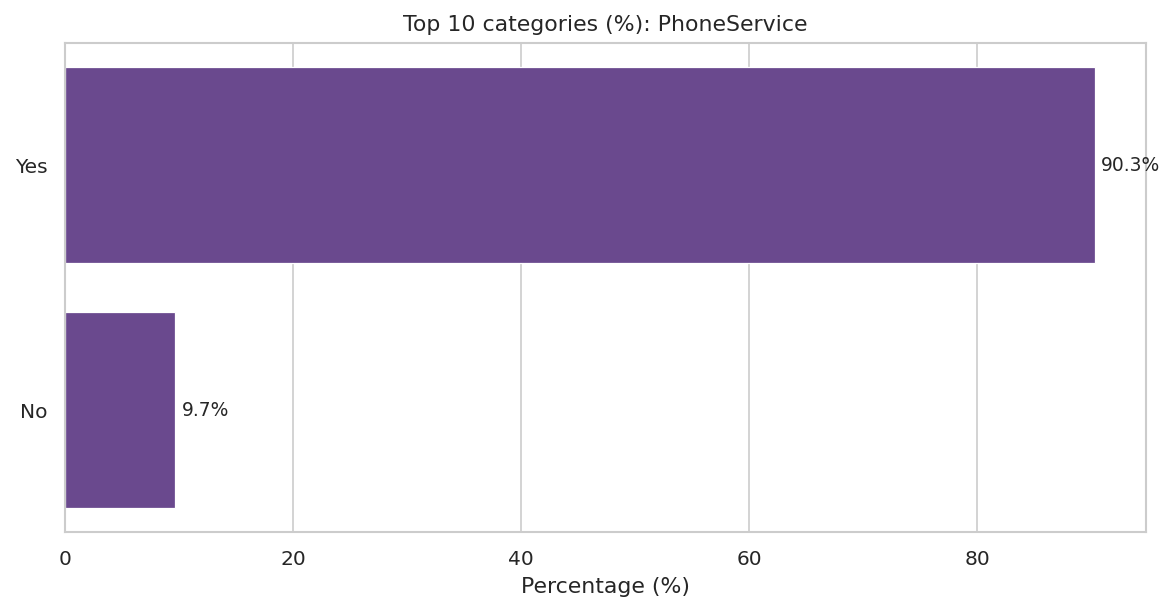

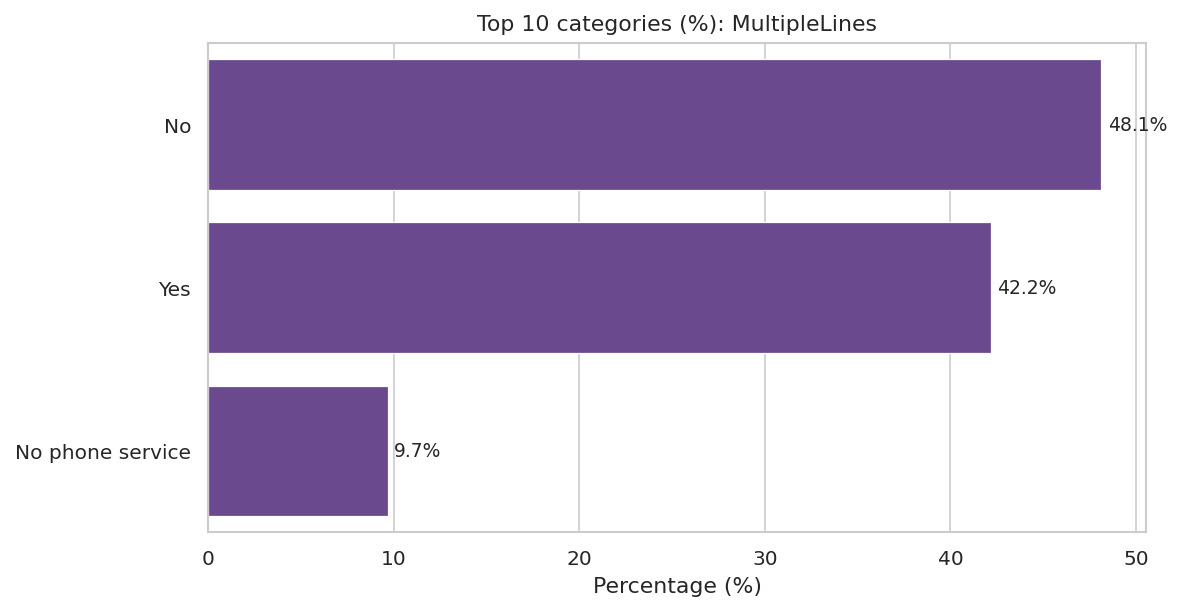

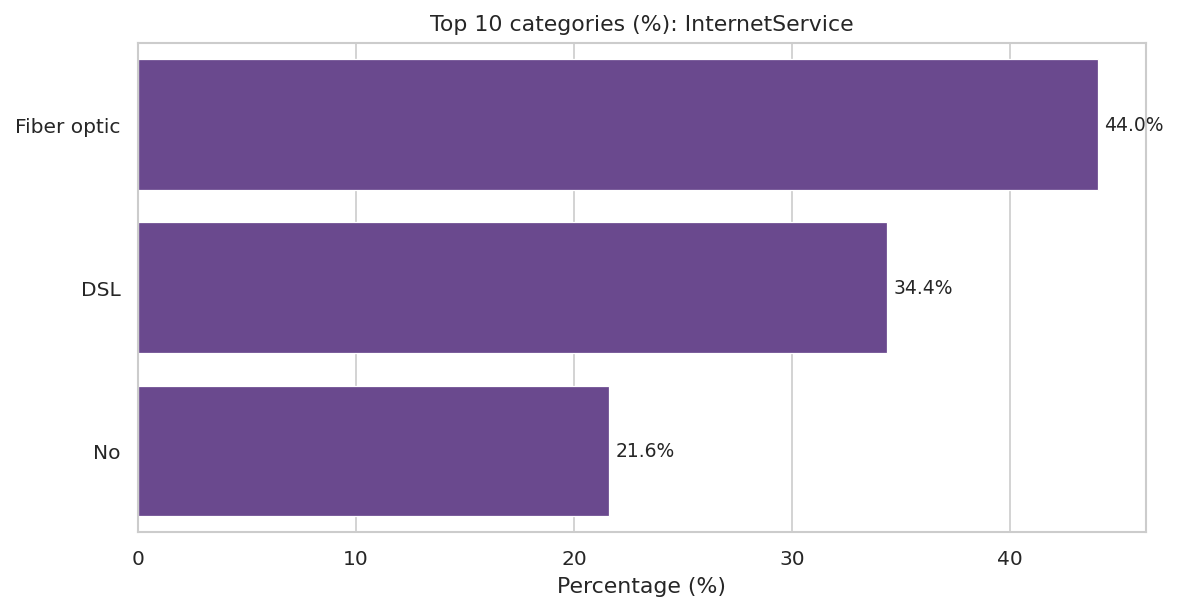

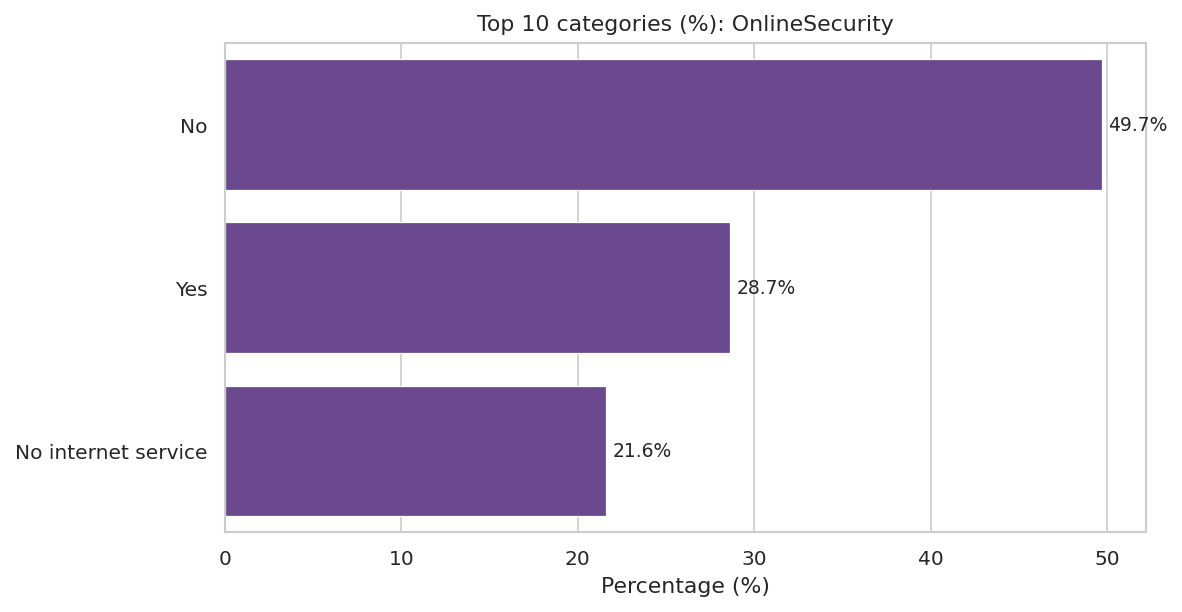

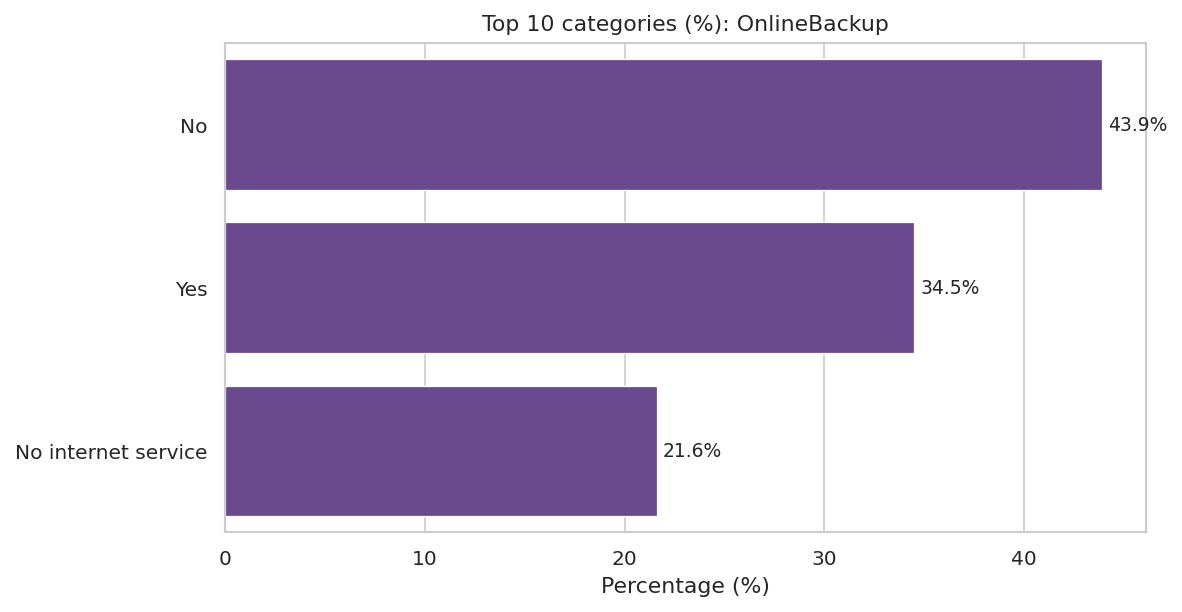

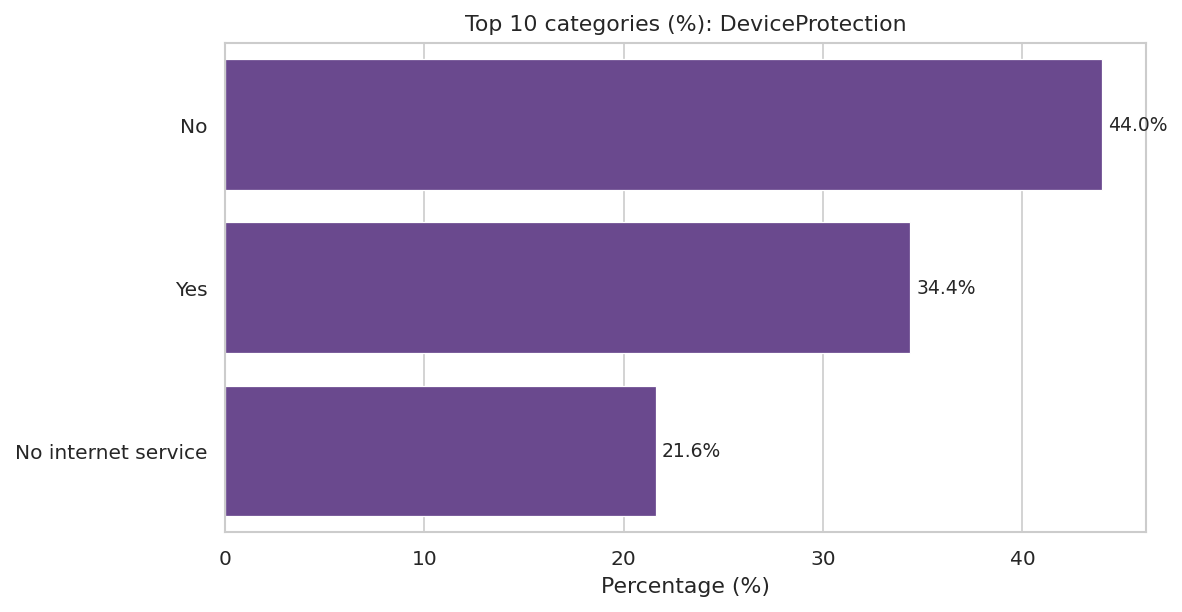

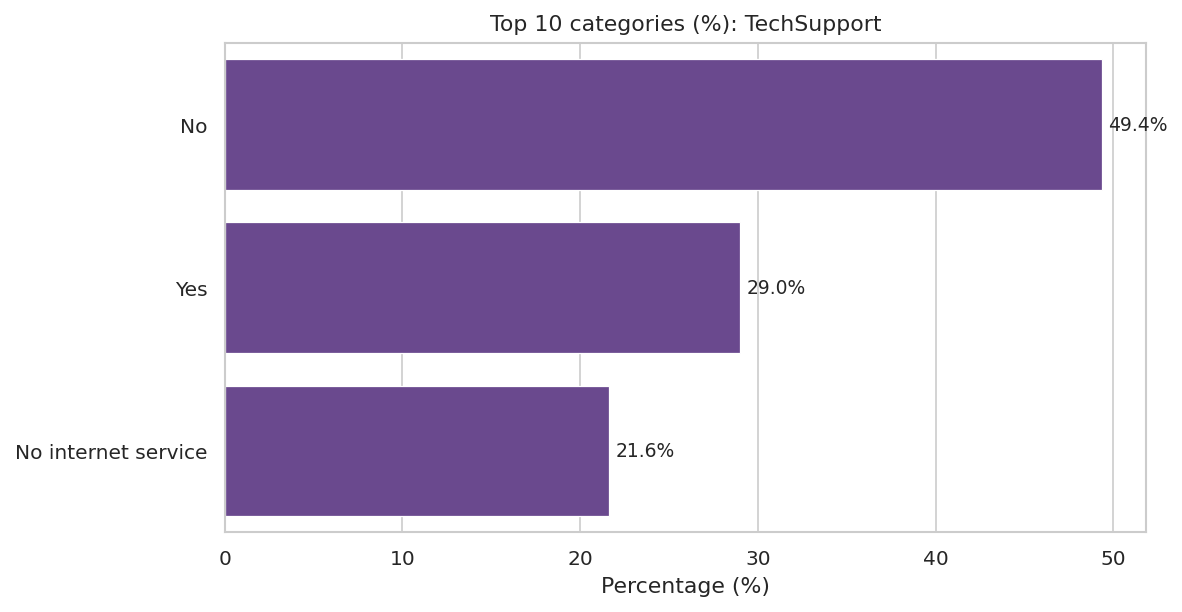

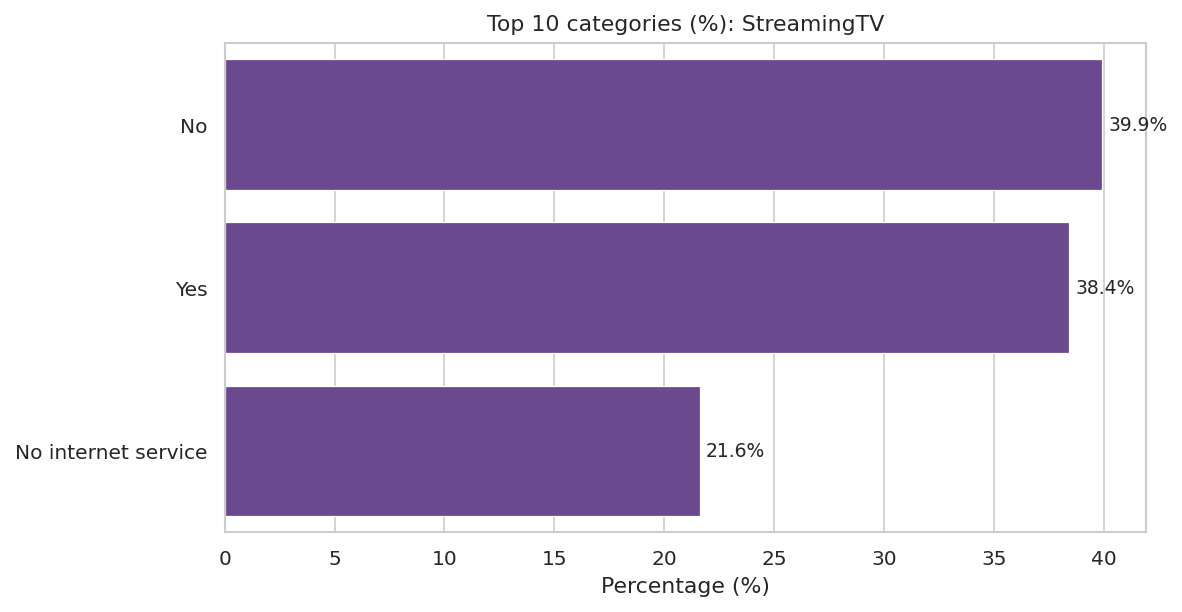

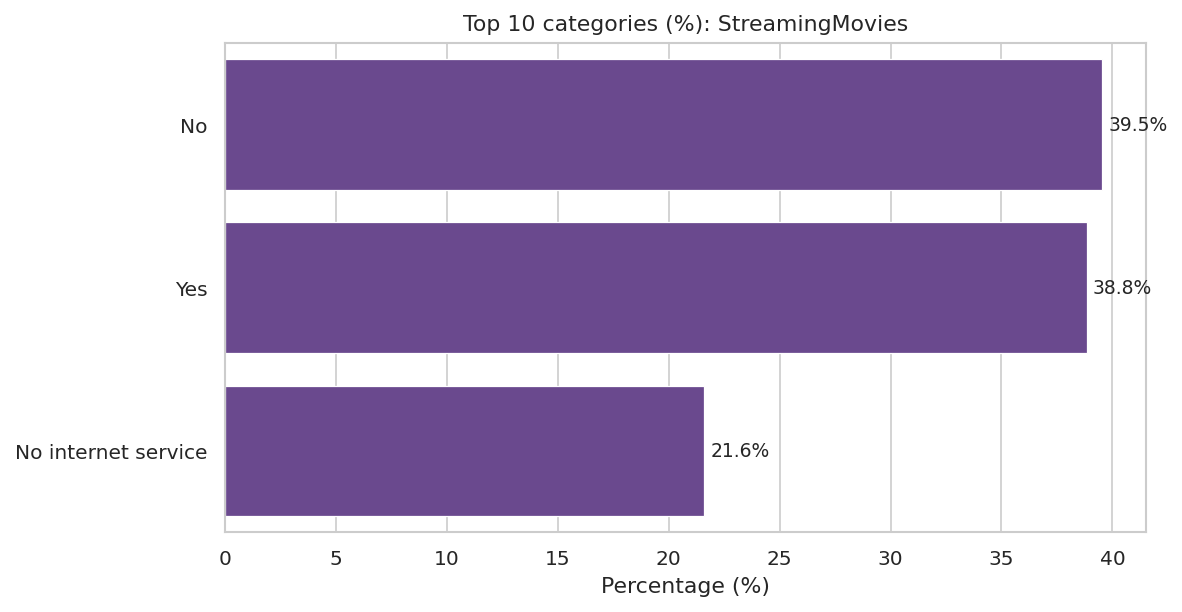

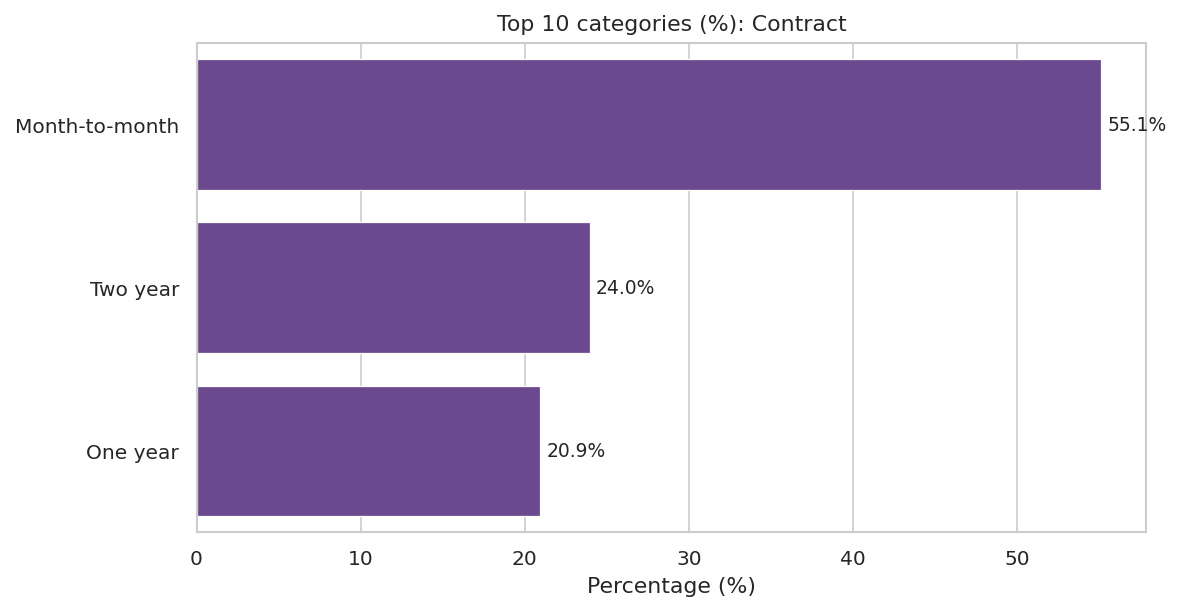

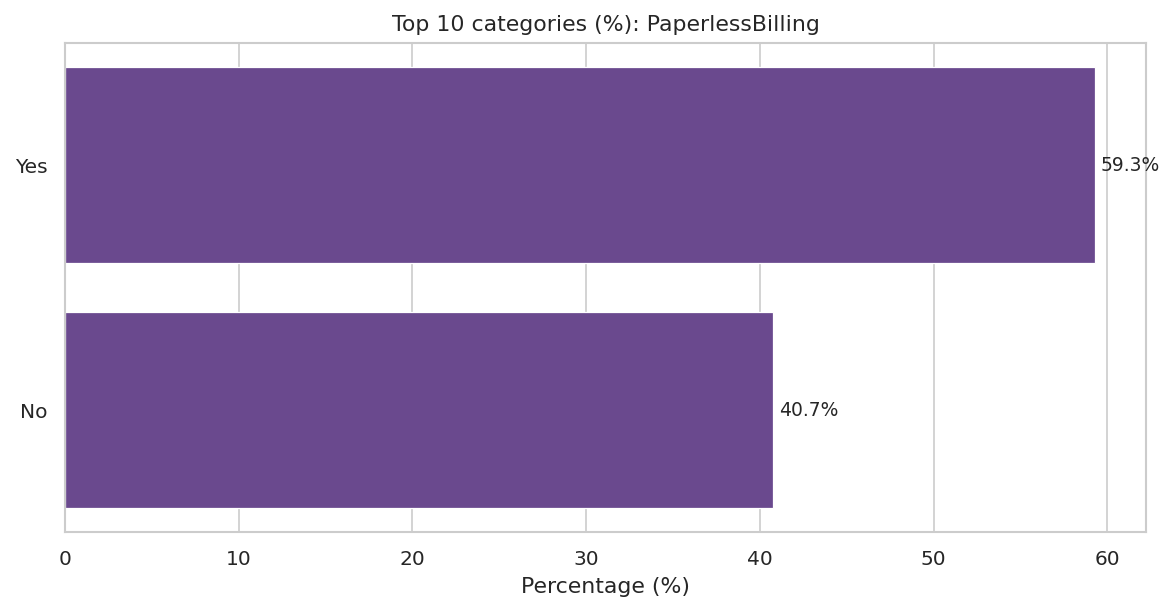

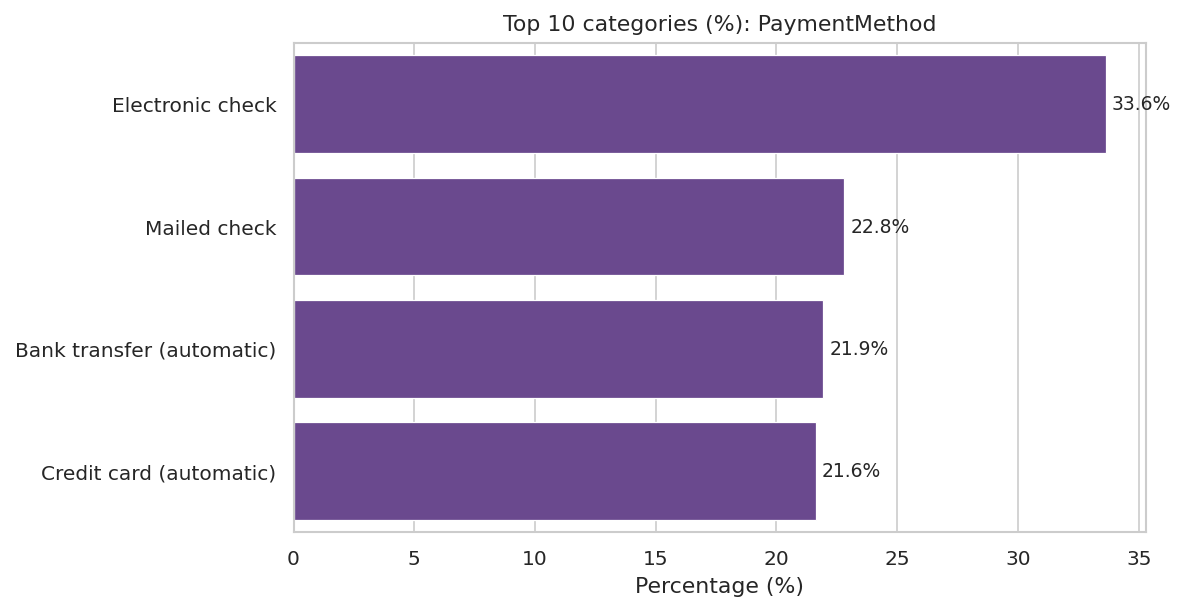

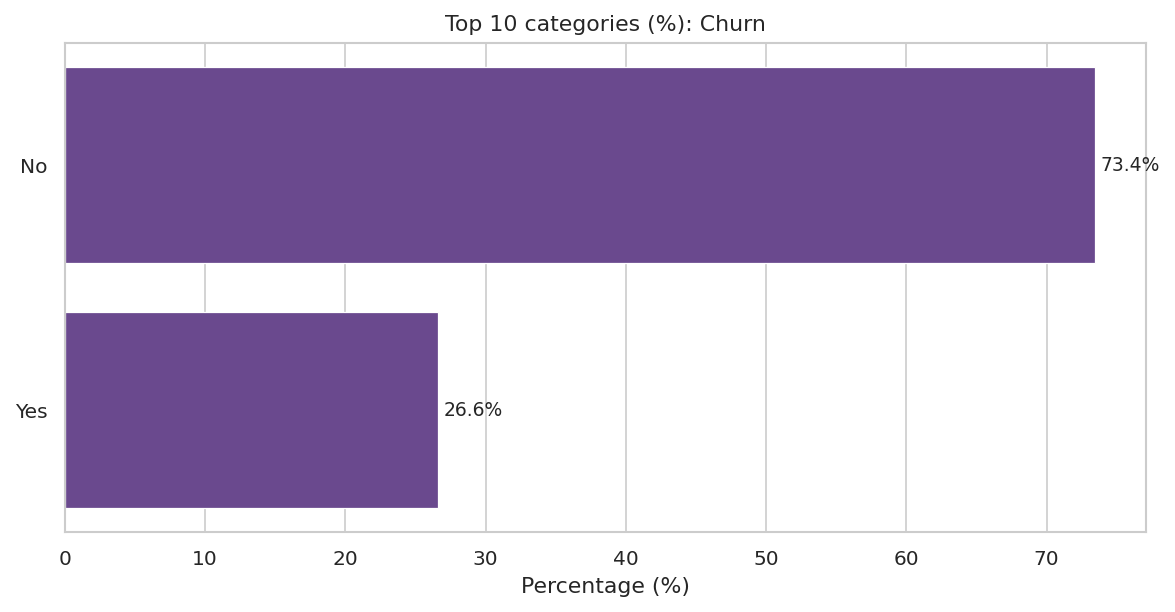

In [ ]:
###5.2 categorical
cat_cols = df_eda.select_dtypes(include=["object"]).columns.tolist()
cat_cols
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ✅ categorical columns بدون customerID
cat_cols = df_eda.select_dtypes(include=["object"]).columns.drop("customerID", errors="ignore")

def plot_top_percent(col, top_n=15, color="#6A3D9A"):  # Purple
    vc = (df_eda[col].value_counts(normalize=True) * 100).head(top_n)

    plt.figure(figsize=(8, 4.2))
    ax = sns.barplot(x=vc.values, y=vc.index, color=color, edgecolor="white", linewidth=0.6)
    ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, fontsize=9)

    plt.title(f"Top {top_n} categories (%): {col}")
    plt.xlabel("Percentage (%)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

# ✅ run for all categorical columns
for col in cat_cols:
    plot_top_percent(col, top_n=10, color="#6A3D9A")

/tmp/ipython-input-707/2227601792.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette=["#13302F", "#131F30"])


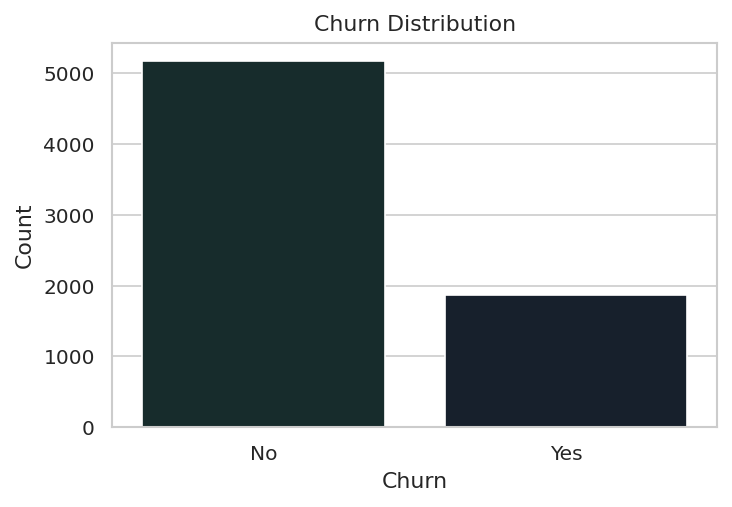

In [ ]:

target = "Churn"
df_eda[target].describe()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3.5))
sns.countplot(x="Churn", data=df, palette=["#13302F", "#131F30"])
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
###########6.Bivariate analysis
# Numeric columns
num_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()

# Categorical columns (object/category/bool)
cat_cols = df_eda.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

# عرض بعض الأعمدة
print("Sample numeric:", num_cols[:10])
print("Sample categorical:", cat_cols[:10])



Numeric columns: 4
Categorical columns: 17
Sample numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Sample categorical: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection']


/tmp/ipython-input-707/1024509382.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x=cat, y=num, palette=palette, ax=ax)
/tmp/ipython-input-707/1024509382.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x=cat, y=num, palette=palette, ax=ax)
/tmp/ipython-input-707/1024509382.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x=cat, y=num, palette=palette, ax=ax)
/tmp/ipython-input-707/1024509382.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed

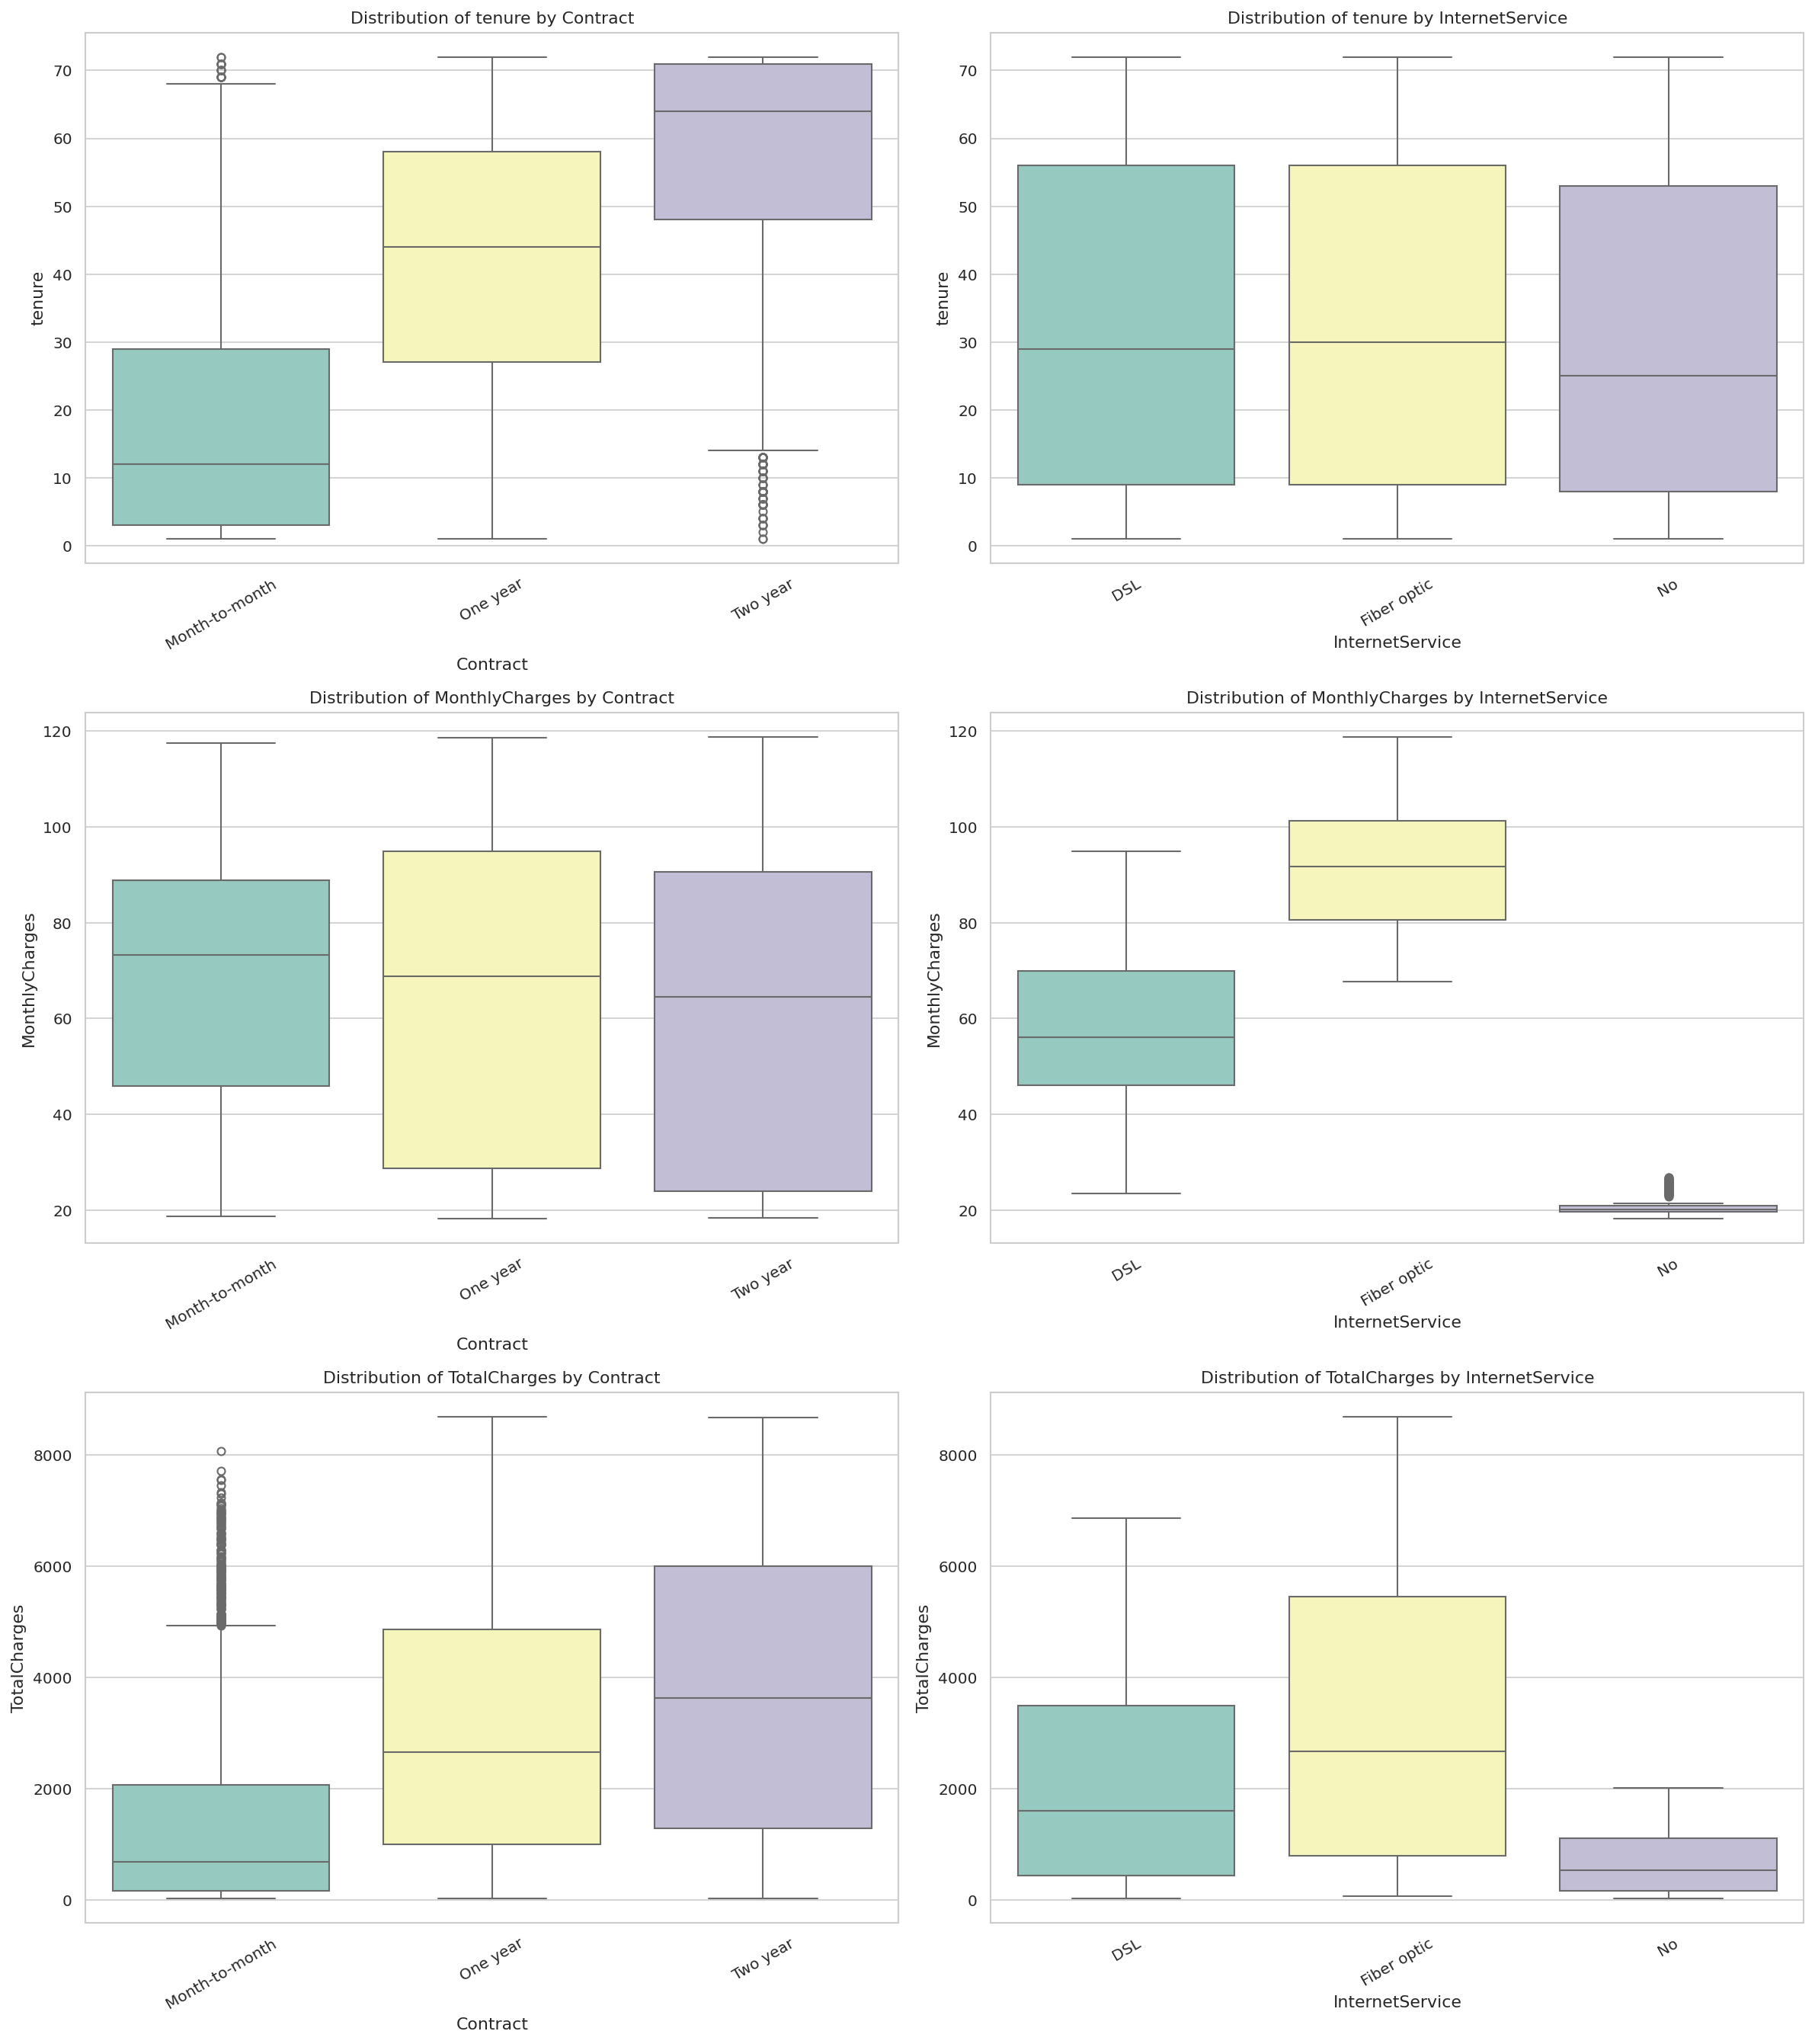

In [ ]:

#### 6.1 Numeric--numeric
# tenure vs churn
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

cat_candidates = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "PaperlessBilling"]
num_candidates = ["tenure", "MonthlyCharges", "TotalCharges", "log_TotalCharges"]

cat_cols = [c for c in cat_candidates if c in df_eda.columns][:2]
num_cols = [n for n in num_candidates if n in df_eda.columns][:3]

if len(cat_cols) < 2:
    auto_cat = [c for c in df_eda.select_dtypes(include=["object","category","bool"]).columns
                if c not in ["customerID","Churn"]]
    cat_cols = (cat_cols + auto_cat)[:2]

if len(num_cols) < 3:
    auto_num = df_eda.select_dtypes(include=["number"]).columns.tolist()
    num_cols = (num_cols + auto_num)[:3]

# 3×2 grid
fig, axes = plt.subplots(3, 2, figsize=(16, 18), sharey=False, sharex=False)

palette = "Set3"

for i, num in enumerate(num_cols):
    for j, cat in enumerate(cat_cols):
        ax = axes[i, j]
        sns.boxplot(data=df_eda, x=cat, y=num, palette=palette, ax=ax)
        ax.set_title(f"Distribution of {num} by {cat}")
        ax.set_ylabel(num)
        ax.set_xlabel(cat)
        ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()


/tmp/ipython-input-707/556543041.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


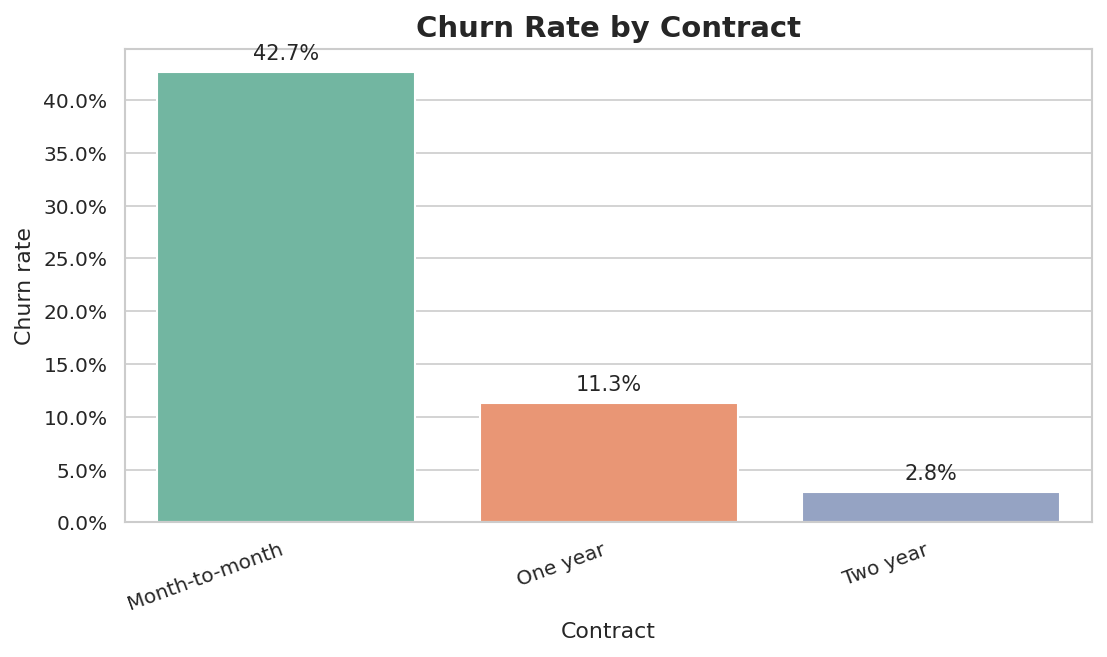

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

sns.set_style("whitegrid")

plt.figure(figsize=(7.5,4.5))
ax = sns.barplot(
    data=rate_contract,
    x="Contract",
    y="Churn_bin",
    palette="Set2",
    edgecolor="white",
    linewidth=1
)

ax.set_title("Churn Rate by Contract", fontsize=14, fontweight="bold")
ax.set_xlabel("Contract")
ax.set_ylabel("Churn rate")

# نخليها % بدل 0-1
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# أرقام فوق الأعمدة
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.1%}",
                (p.get_x() + p.get_width()/2, h),
                ha="center", va="bottom",
                fontsize=10,
                xytext=(0, 4),
                textcoords="offset points")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipython-input-707/4022628515.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


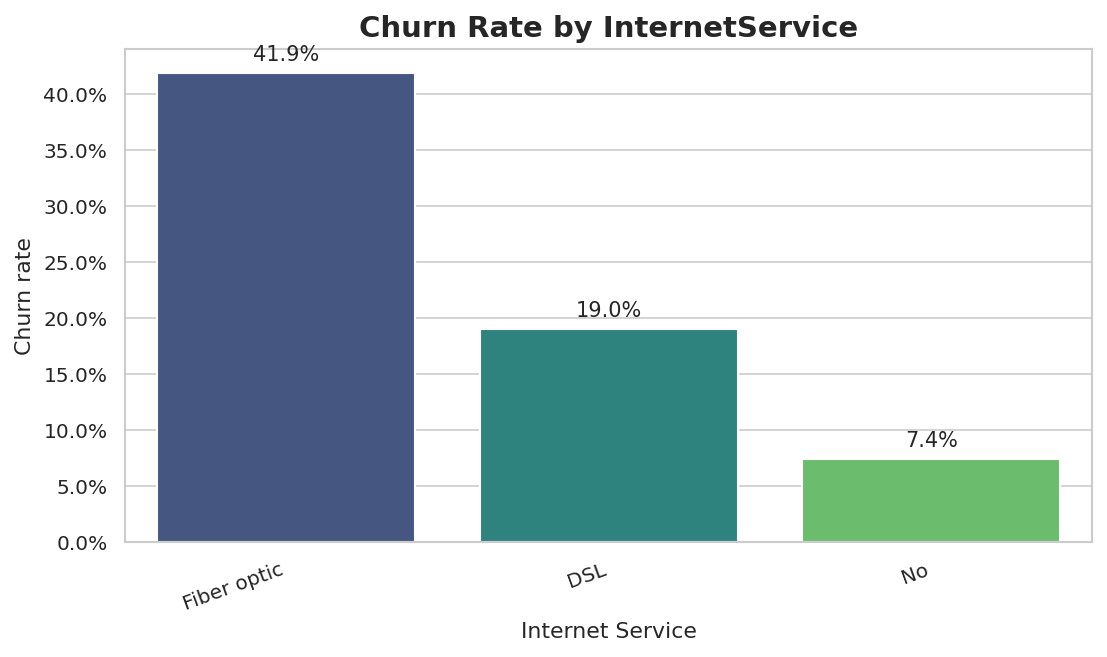

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

sns.set_style("whitegrid")

plt.figure(figsize=(7.5,4.5))
ax = sns.barplot(
    data=rate_net,
    x="InternetService",
    y="Churn_bin",
    palette=sns.color_palette("viridis", n_colors=len(rate_net)),
    edgecolor="white",
    linewidth=1
)

ax.set_title("Churn Rate by InternetService", fontsize=14, fontweight="bold")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Churn rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.1%}",
                (p.get_x() + p.get_width()/2, h),
                ha="center", va="bottom",
                fontsize=10,
                xytext=(0, 4),
                textcoords="offset points")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

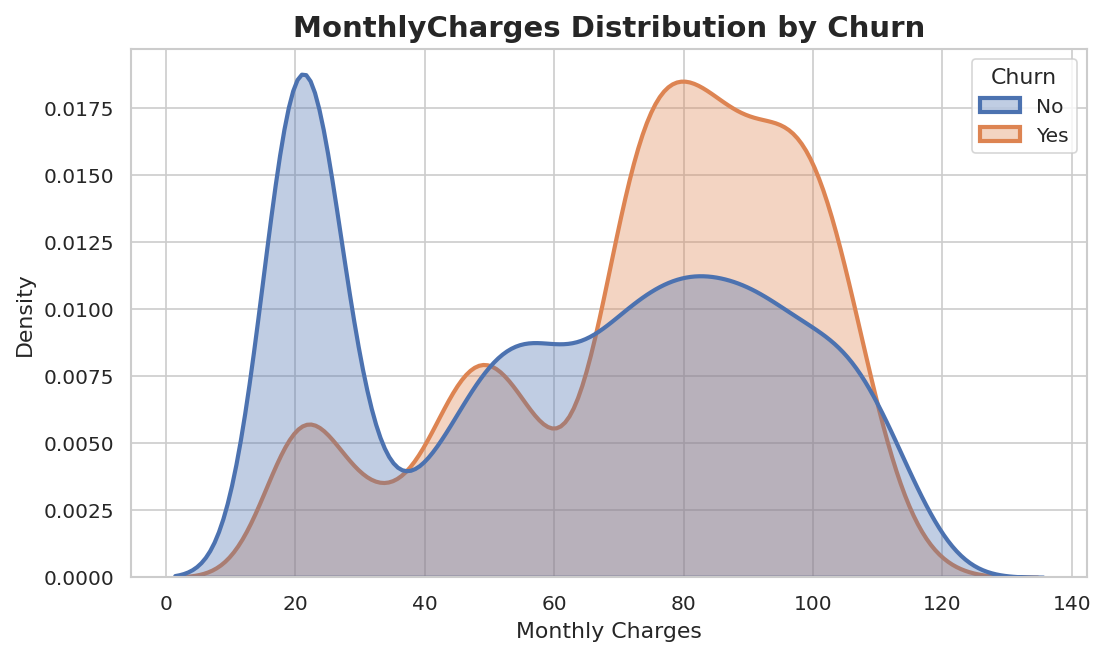

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7.5,4.5))
sns.kdeplot(
    data=df_eda, x="MonthlyCharges", hue="Churn",
    fill=True, alpha=0.35,
    common_norm=False,
    linewidth=2
)
plt.title("MonthlyCharges Distribution by Churn", fontsize=14, fontweight="bold")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

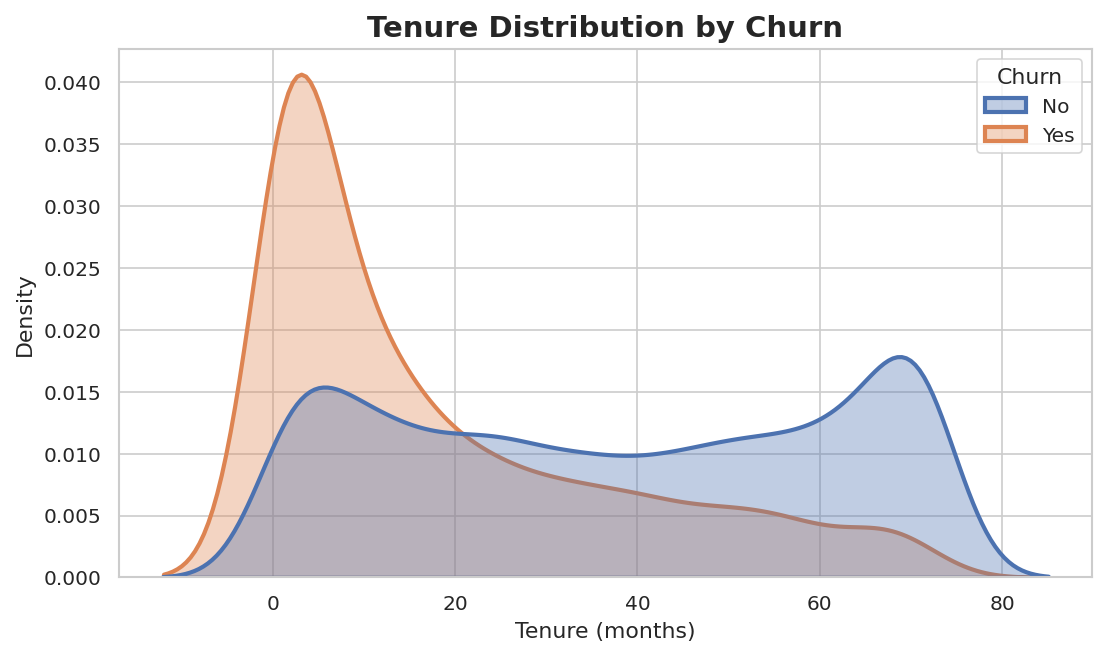

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7.5,4.5))
sns.kdeplot(
    data=df_eda, x="tenure", hue="Churn",
    fill=True, alpha=0.35,
    common_norm=False,
    linewidth=2
)
plt.title("Tenure Distribution by Churn", fontsize=14, fontweight="bold")
plt.xlabel("Tenure (months)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

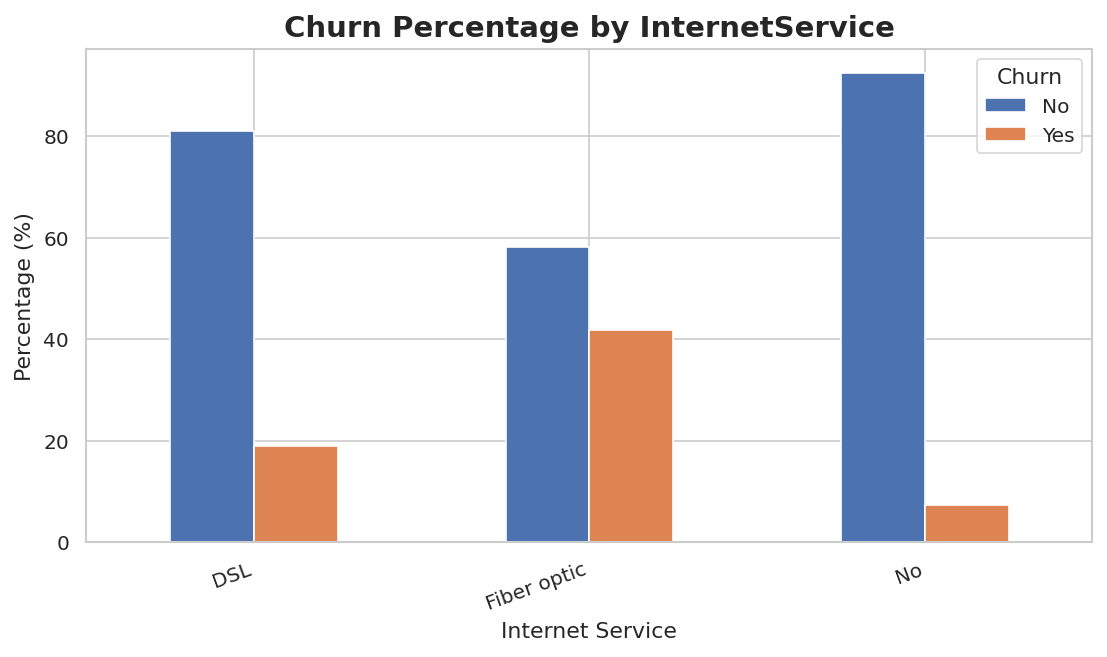

In [ ]:
import pandas as pd

ct = pd.crosstab(df_eda["InternetService"], df_eda["Churn"], normalize="index") * 100
ct = ct[["No","Yes"]]  # ترتيب أعمدة

ax = ct.plot(kind="bar", figsize=(7.5,4.5))
plt.title("Churn Percentage by InternetService", fontsize=14, fontweight="bold")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

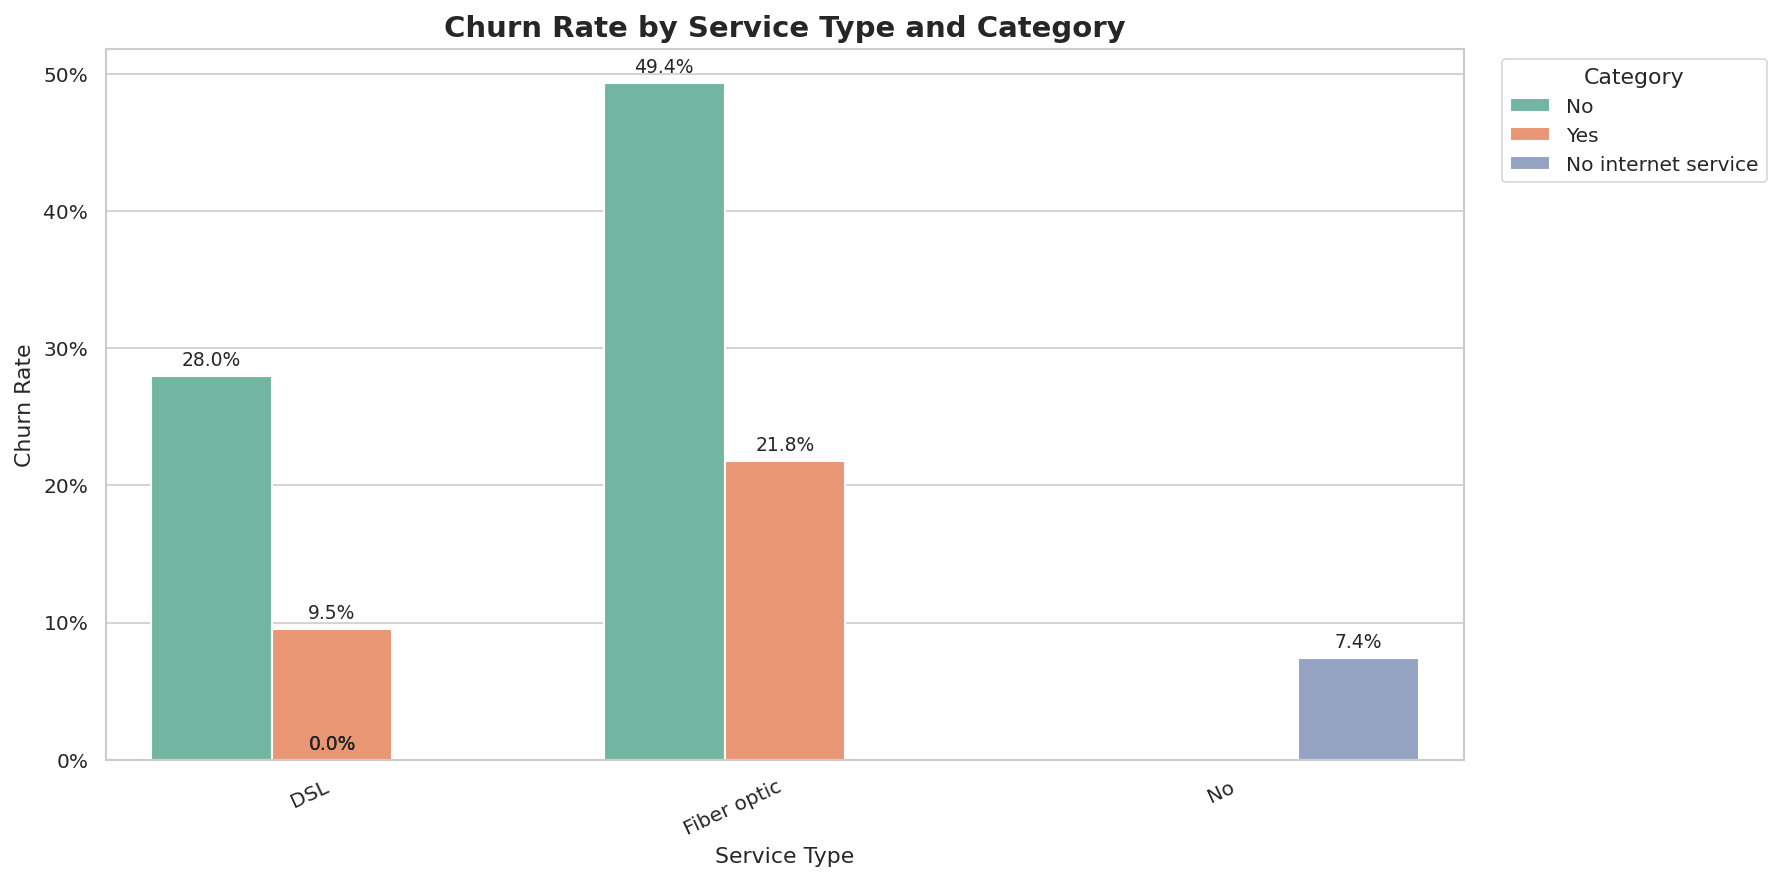

In [ ]:
import pandas as pd
import numpy as np

# 1) churn bin
df_eda["Churn_bin"] = df_eda["Churn"].map({"No":0, "Yes":1})

service_col = "InternetService"
category_col = "OnlineSecurity"

# 3) Build churn_comparison
churn_comparison = (
    df_eda.groupby([service_col, category_col])["Churn_bin"]
    .mean()
    .reset_index()
    .rename(columns={
        service_col: "Service_Type",
        category_col: "Category",
        "Churn_bin": "Churn_Rate"
    })
)

churn_comparison.head()

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

sns.set_style("whitegrid")

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=churn_comparison,
    x="Service_Type",
    y="Churn_Rate",
    hue="Category",
    palette="Set2",          #  "Set2" / "Set3" / "Paired"
    edgecolor="white",
    linewidth=1
)

ax.set_title("Churn Rate by Service Type and Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Service Type")
ax.set_ylabel("Churn Rate")

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for p in ax.patches:
    h = p.get_height()
    if h == h:  # يتجنب NaN
        ax.annotate(f"{h:.1%}",
                    (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom",
                    fontsize=9,
                    xytext=(0, 3),
                    textcoords="offset points")

plt.xticks(rotation=25, ha="right")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

/tmp/ipython-input-707/95131323.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = (df_eda.groupby(["TenureGroup", "Contract"])["Churn_bin"]


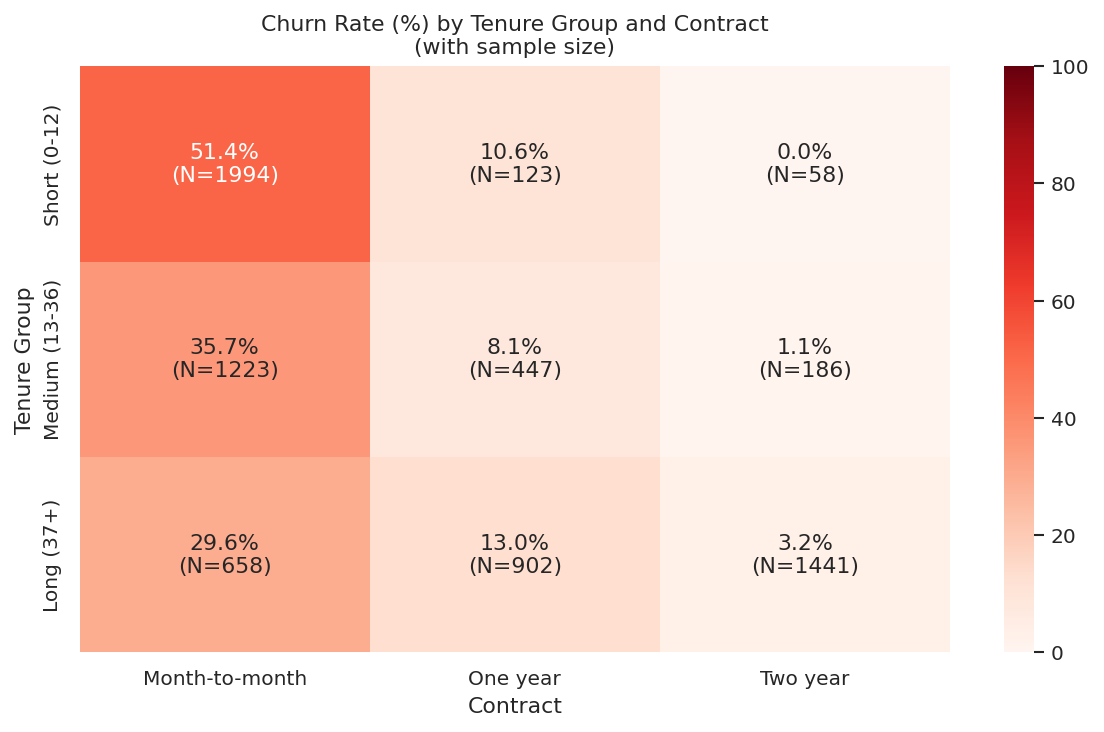

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

if "Churn_bin" not in df_eda.columns:
    df_eda["Churn_bin"] = df_eda["Churn"].map({"No":0, "Yes":1})

if "TenureGroup" not in df_eda.columns:
    df_eda["TenureGroup"] = pd.cut(
        df_eda["tenure"],
        bins=[0, 12, 36, 72],
        labels=["Short (0-12)", "Medium (13-36)", "Long (37+)"],
        include_lowest=True
    )

agg = (df_eda.groupby(["TenureGroup", "Contract"])["Churn_bin"]
       .agg(rate="mean", n="size")
       .reset_index())

agg["rate_pct"] = agg["rate"] * 100

heat_rate = agg.pivot(index="TenureGroup", columns="Contract", values="rate_pct")
heat_n    = agg.pivot(index="TenureGroup", columns="Contract", values="n")

annot = heat_rate.copy().astype(str)
for r in annot.index:
    for c in annot.columns:
        rp = heat_rate.loc[r, c]
        nn = heat_n.loc[r, c]
        if pd.isna(rp) or pd.isna(nn):
            annot.loc[r, c] = ""
        else:
            annot.loc[r, c] = f"{rp:.1f}%\n(N={int(nn)})"

# 6) Plot
plt.figure(figsize=(8,5))
sns.heatmap(heat_rate, annot=annot, fmt="", cmap="Reds", vmin=0, vmax=100)
plt.title("Churn Rate (%) by Tenure Group and Contract\n(with sample size)")
plt.xlabel("Contract")
plt.ylabel("Tenure Group")
plt.tight_layout()
plt.show()